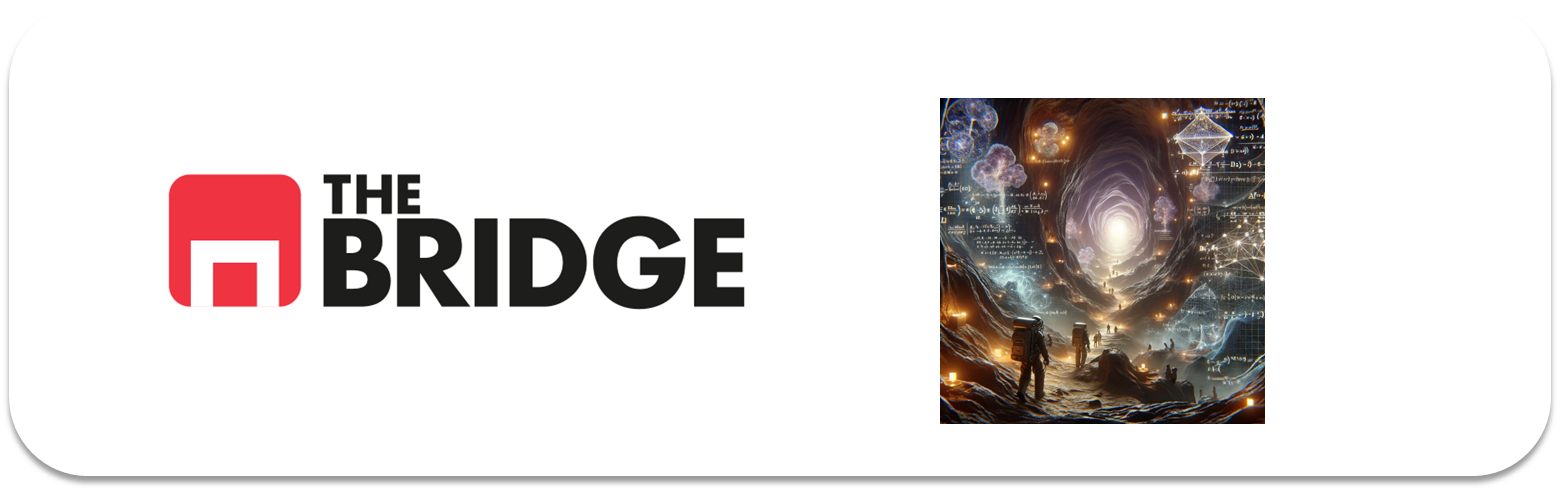

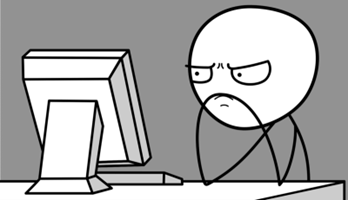

Para ejercitarte y afianzar lo aprendido sobre nuestra **Introducción a Deep Learning**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

# Bank marketing dataset - Depósito a plazo fijo

En este notebook vamos repasar un modelo que ya hicimos en anteriores ocasiones que nos permitía predecir si un individuo dependiendo de sus características, así como características de la campaña de marketing a la cual se pretende asignarlo, va a adquirir un servicio bancario (en este caso, un depósito a plazo fijo). El objetivo de este ejercicio será, mas allá de obtener un modelo preciso o hacer un análisis de datos exhaustivo, observar las posibles diferencias entre el utilizar un modelo de regresión logística o uno de MLP (multi-layer perceptron) para predecir nuestra variable categórica (sí adquiere, no adquiere).

Obtenemos los datos a partir del "*UCI Machine Learning repository*".

### *Features*:

#### Datos del cliente:

1. **age** (edad)
2. **job** (tipo de trabajo)
3. **marital** (estado marital)
4. **education** (nivel de eduación)
5. **default** (fallo en pagar una deuda)
6. **housing** (si tiene un préstamo de vivienda)
7. **loan** (si tiene un préstamo personal)
8. **balance** (balance personal)

#### Datos del último contacto de la campaña de marketing en curso:

9. **contact** (tipo de contacto)
10. **month** (último mes de contacto)
11. **day** (último día de contacto)
12. **duration** (duración de la llamada en segundos; duration = 0 significa no contactados)

#### Otros

13. **campaign** (número de contactos al cliente hechos en esta campaña)
14. **pdays** (número de días que han pasado desde que el cliente fue contactado en una campaña anterior; 999 o -1 significa que el cliente no ha sido contactado)
15. **previous** (número de contactos realizados antes de esta campaña a el cliente)
16. **poutcome** (resultado de la campaña anterior)
17. **deposit** (target)

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
# Tratamiento de datos
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Utilidades de visualización del bootcamp (está en la misma carpeta que el notebook)
import bootcampviztools as bvt

# Modelado
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

# Semilla única para todo el notebook, así los resultados son reproducibles
SEED = 42

# El MLP avisa de "no convergencia" con frecuencia; silenciamos para no ensuciar la salida
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

print("Librerías importadas correctamente")

Librerías importadas correctamente


### Ejercicios 1

Importa los datos y echa un vistazo rápido. Selecciona la variable target y asignala a una variable "target".

In [2]:
# Cargamos los datos
df = pd.read_csv("./data/bank.csv")

print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (11162, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [3]:
# Vistazo rápido a tipos de dato y nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   contact    11162 non-null  str  
 9   day        11162 non-null  int64
 10  month      11162 non-null  str  
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  int64
 15  poutcome   11162 non-null  str  
 16  deposit    11162 non-null  str  
dtypes: int64(7), str(10)
memory usage: 1.4 MB


El dataset tiene **11.162 filas y 17 columnas**, y lo mejor de todo: **no hay ningún nulo**,
así que nos ahorramos toda la parte de imputación.

Tenemos una mezcla de variables numéricas (`age`, `balance`, `duration`...) y categóricas de tipo
texto (`job`, `marital`, `education`...). La columna **`deposit`** es la que queremos predecir:
indica si el cliente contrató o no el depósito a plazo fijo.

In [4]:
# Guardamos el nombre del target en una variable, como pide el enunciado
target = "deposit"

# Vemos cómo se reparte el target antes de tocar nada
print(df[target].value_counts())
print()
print(df[target].value_counts(normalize=True).round(4))

deposit
no     5873
yes    5289
Name: count, dtype: int64

deposit
no     0.5262
yes    0.4738
Name: proportion, dtype: float64


### Ejercicio 2

Haz el split en train y test y analiza el target.

In [5]:
# El target es categórico con dos valores ("yes"/"no"), lo pasamos a 0/1
# para poder usarlo en los modelos y en las métricas de sklearn
df[target] = df[target].map({"no": 0, "yes": 1})

# Split en train y test. Usamos stratify para mantener la proporción del
# target en ambos conjuntos (buena práctica en clasificación)
train_set, test_set = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df[target],
)

print("Train:", train_set.shape)
print("Test :", test_set.shape)

Train: (8929, 17)
Test : (2233, 17)


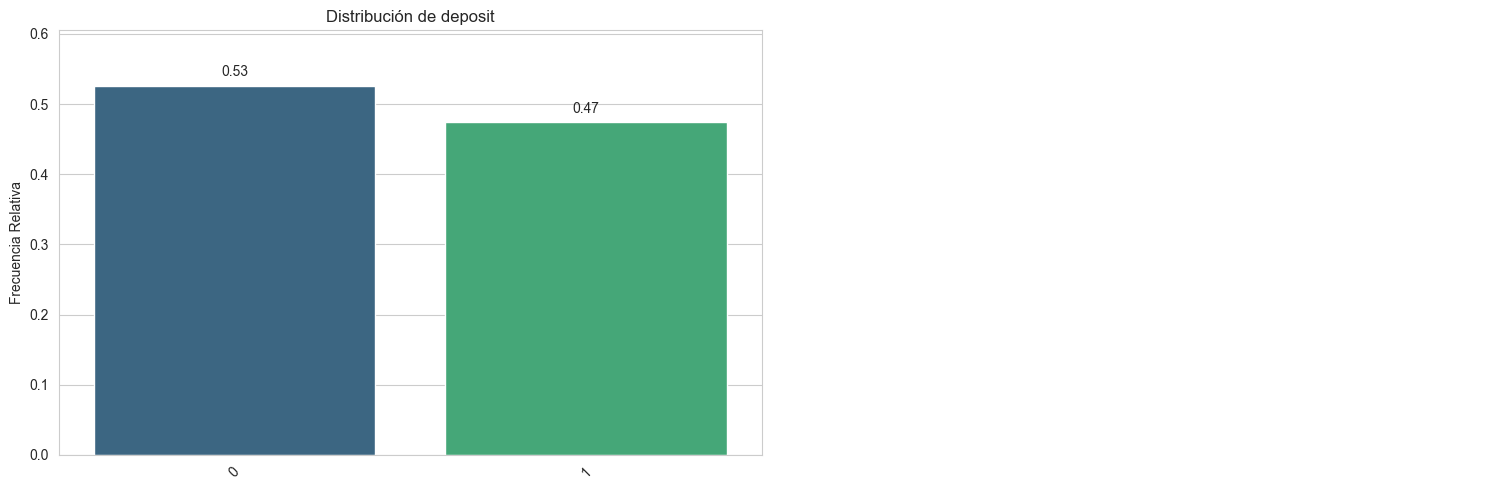

In [6]:
# Analizamos el target en el conjunto de TRAIN (es el que usaremos para entrenar).
# Usamos la función del bootcamp para pintar la distribución de una categórica.
bvt.pinta_distribucion_categoricas(
    train_set,
    [target],
    relativa=True,
    mostrar_valores=True,
)

**Análisis del target:** el reparto es de aproximadamente **53% de "no" (0) frente a 47% de "yes" (1)**.

Es un dataset prácticamente **balanceado**, lo cual es una buena noticia: podemos usar el *accuracy*
como métrica principal sin que nos engañe (con clases muy desbalanceadas el accuracy es traicionero,
porque un modelo que prediga siempre la clase mayoritaria ya acertaría mucho). Aun así miraremos
también precision y recall para tener la foto completa.

### Ejercicio 3

Tienes múltiples variables tipo object y algunas numéricas, en este caso quédate solo con las variables numéricas y el target. Observa las distribuciones de dichas variables numéricas

In [7]:
# Nos quedamos solo con las columnas numéricas (el target ya es numérico tras el mapeo)
num_cols = train_set.select_dtypes(include="number").columns.tolist()
num_cols.remove(target)  # separamos el target de las features

print("Features numéricas ({}): {}".format(len(num_cols), num_cols))

# Creamos una versión reducida del train con features numéricas + target
train_num = train_set[num_cols + [target]].copy()
train_num.head()

Features numéricas (7): ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


,age,balance,day,duration,campaign,pdays,previous,deposit
8644,46,526,31,251,3,-1,0,0
2632,46,2552,3,260,1,94,8,1
3056,25,139,11,202,1,91,1,1
1080,43,3288,21,775,3,-1,0,1
4006,37,217,23,272,2,-1,0,1


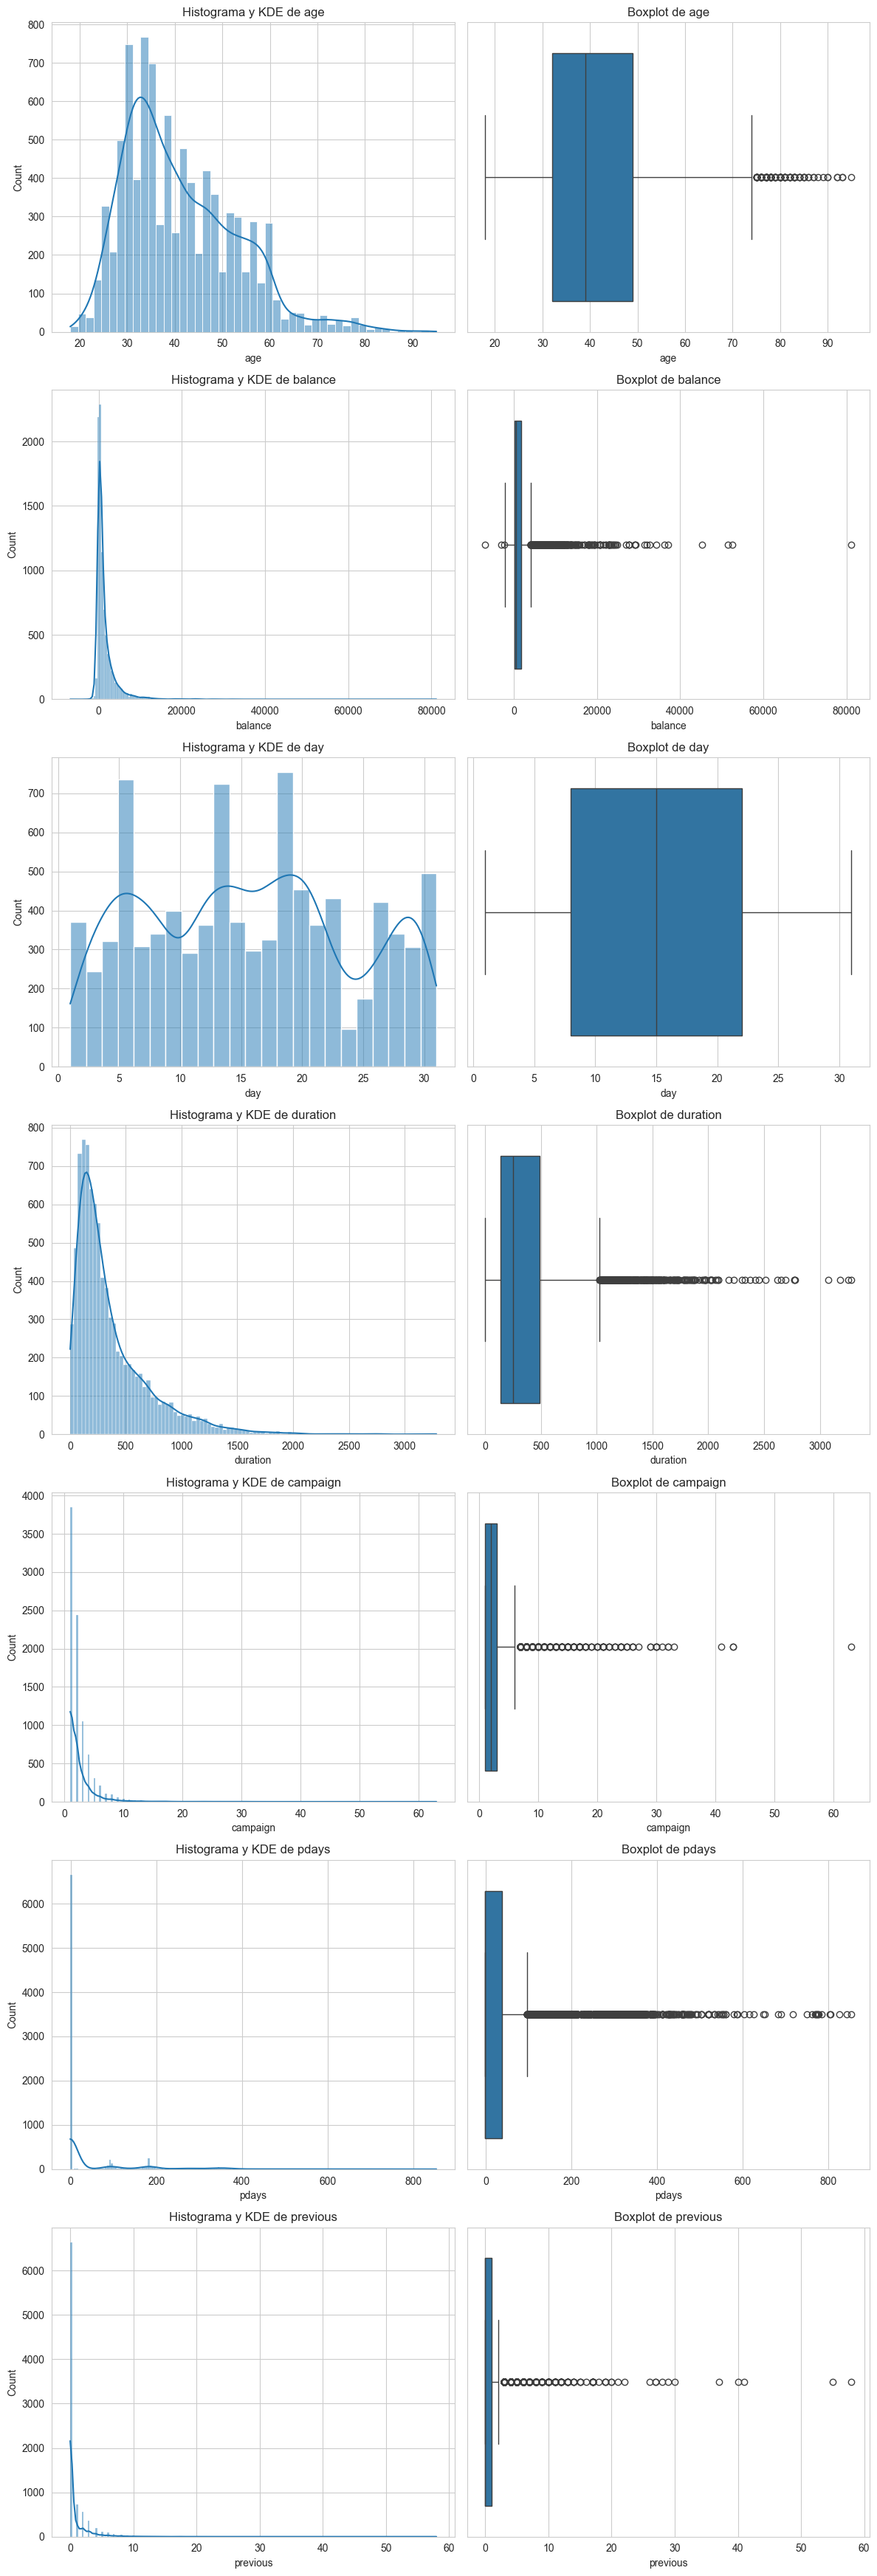

In [8]:
# Observamos las distribuciones de las variables numéricas.
# plot_combined_graphs pinta, para cada variable, un histograma con KDE y un boxplot.
bvt.plot_combined_graphs(train_num, num_cols)

**¿Qué vemos en las distribuciones?**

- **`age`**: concentrada entre los 30 y los 50 años, con una cola hacia la derecha (clientes mayores).
- **`balance`**: muy asimétrica, con muchísimos outliers a la derecha. Hay incluso saldos negativos
  (clientes en números rojos).
- **`day`**: bastante uniforme, es simplemente el día del mes en que se hizo la llamada. No parece
  que vaya a aportar mucho.
- **`duration`**: asimétrica a la derecha. Es la duración de la última llamada.
- **`campaign`**, **`pdays`** y **`previous`**: muy concentradas en valores bajos y con outliers.
  Ojo con `pdays`, que usa **-1 como valor especial** para indicar "a este cliente no se le había
  contactado antes", no es un número de días real.

En general son variables con distribuciones muy poco normales y con bastantes outliers. Esto refuerza
la necesidad de **escalar** antes de entrenar (Ejercicio 5).

### Ejercicio 4

A partir de las features del ejercicio 3, realiza una selección de features sencilla, utiliza la técnica que consideres conveniente y quedate con 4 features.

In [9]:
# Técnica elegida: información mutua (mutual_info_classif).
# La usamos porque, a diferencia de la correlación, detecta también relaciones
# NO lineales entre cada feature y el target, y es muy directa de interpretar:
# a mayor valor, más información aporta la feature sobre el target.
#
# IMPORTANTE: la información mutua se estima con un método aleatorio (basado en
# vecinos más cercanos), así que fijamos random_state para obtener siempre lo mismo.
mi_scores = mutual_info_classif(
    train_num[num_cols],
    train_num[target],
    random_state=SEED,
)

# Lo guardamos en una Serie ordenada de mayor a menor para verlo cómodamente
mi_scores = pd.Series(mi_scores, index=num_cols).sort_values(ascending=False)
print(mi_scores.round(4))

duration    0.1593
balance     0.0405
pdays       0.0383
previous    0.0214
age         0.0182
campaign    0.0163
day         0.0107
dtype: float64


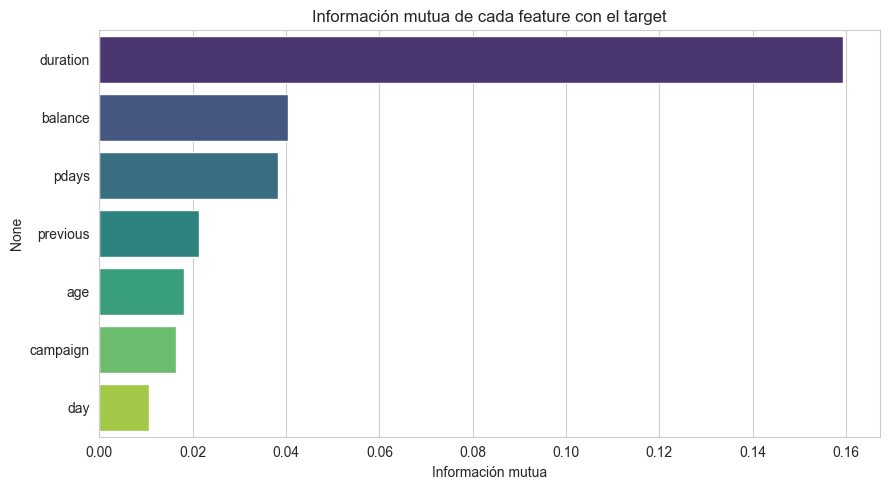

In [10]:
# Lo visualizamos para verlo de un golpe de vista
plt.figure(figsize=(9, 5))
sns.barplot(x=mi_scores.values, y=mi_scores.index, hue=mi_scores.index,
            palette="viridis", legend=False)
plt.title("Información mutua de cada feature con el target")
plt.xlabel("Información mutua")
plt.tight_layout()
plt.show()

In [11]:
# Nos quedamos con las 4 features con mayor información mutua
features = mi_scores.head(4).index.tolist()
print("Features seleccionadas:", features)

Features seleccionadas: ['duration', 'balance', 'pdays', 'previous']


**Conclusión de la selección:** `duration` destaca muchísimo sobre el resto (su información mutua es
casi 4 veces la de la siguiente), y después vienen `balance`, `pdays` y `previous`. Las descartadas
(`age`, `campaign`, `day`) aportan muy poquito, especialmente `day`, que era justo la que
sospechábamos por su distribución uniforme.

> **Nota honesta sobre `duration`:** en un proyecto real esta feature sería discutible. `duration` es
> la duración de la llamada, así que **solo la conocemos DESPUÉS de haber llamado al cliente**. Si el
> objetivo es decidir a quién llamar, no dispondríamos de ese dato en el momento de la predicción
> (es lo que se llama *data leakage* temporal). Como este ejercicio se centra en comparar Regresión
> Logística y MLP, la mantenemos, pero conviene tenerlo presente.

### Ejercicio 5

Crea los pares X,y para train y test y escala los datos. ¿Por qué debemos hacerlo?

In [12]:
# Creamos los pares X, y para train y test usando SOLO las 4 features seleccionadas
X_train = train_set[features]
y_train = train_set[target]

X_test = test_set[features]
y_test = test_set[target]

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test :", X_test.shape, "| y_test :", y_test.shape)

# Escalado: ajustamos el scaler SOLO con train y luego transformamos ambos.
# Si lo ajustásemos con todo el dataset estaríamos filtrando información del test
# al entrenamiento (data leakage).
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Comprobamos que tras escalar la media es ~0 y la desviación ~1
print("\nMedia por feature tras escalar:", np.round(X_train_scaled.mean(axis=0), 3))
print("Desv. típica por feature tras escalar:", np.round(X_train_scaled.std(axis=0), 3))

X_train: (8929, 4) | y_train: (8929,)
X_test : (2233, 4) | y_test : (2233,)

Media por feature tras escalar: [ 0. -0. -0. -0.]
Desv. típica por feature tras escalar: [1. 1. 1. 1.]


### Respuesta: ¿por qué hay que escalar?

Porque **ambos modelos son sensibles a la escala de las variables**, y en nuestro caso las features
tienen rangos completamente distintos: `balance` llega a decenas de miles mientras que `previous` se
mueve entre 0 y unos pocos.

- El **MLP entrena por descenso del gradiente**. Si una feature tiene valores mucho mayores que las
  demás, domina el cálculo del gradiente y la superficie de error queda "deformada": el optimizador
  avanza en zigzag y le cuesta mucho más converger (o directamente no converge). Es exactamente lo
  que vimos en el workout con el dataset de pingüinos, donde el modelo pasaba de un desastre a un
  buen resultado **solo con escalar**.
- La **regresión logística** también se optimiza iterativamente, así que se beneficia igualmente:
  converge antes y los coeficientes son comparables entre sí.

Usamos `StandardScaler` (media 0, desviación típica 1) porque nuestras 4 features son todas
numéricas continuas y con outliers; a diferencia del workout, aquí no tenemos variables dummy 0/1
que nos empujen a preferir el `MinMaxScaler`.

Antes de entrenar, creamos una pequeña función auxiliar. Como a los dos modelos les vamos a pedir
exactamente lo mismo (métricas + tiempos), así no repetimos código y nos aseguramos de medirlo todo
igual en ambos casos.

In [13]:
def entrena_y_evalua(modelo, nombre, X_train, y_train, X_test, y_test):
    """
    Entrena un modelo, mide sus tiempos y muestra sus métricas.

    Argumentos:
        modelo: estimador de sklearn ya configurado.
        nombre (str): nombre del modelo, para mostrarlo por pantalla.
        X_train, y_train: datos de entrenamiento.
        X_test, y_test: datos de prueba.

    Retorna:
        dict: métricas y tiempos, para poder compararlos luego en una tabla.
    """
    # Medimos el tiempo de ENTRENAMIENTO
    inicio = time.time()
    modelo.fit(X_train, y_train)
    t_entrenamiento = time.time() - inicio

    # Medimos el tiempo de PREDICCIÓN
    inicio = time.time()
    y_pred = modelo.predict(X_test)
    t_prediccion = time.time() - inicio

    # Mostramos el informe completo por pantalla
    print("=" * 60)
    print(nombre)
    print("=" * 60)
    print("Tiempo de entrenamiento: {:.4f} s".format(t_entrenamiento))
    print("Tiempo de predicción   : {:.4f} s".format(t_prediccion))
    print()
    print(classification_report(y_test, y_pred, digits=3))

    # Matriz de confusión
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
    plt.title("Matriz de confusión - {}".format(nombre))
    plt.show()

    # Devolvemos las métricas en un diccionario para la comparativa final
    return {
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "t_entrenamiento_s": t_entrenamiento,
        "t_prediccion_s": t_prediccion,
    }

### Ejercicio 6

 Crea un modelo de regresión logistica y observa sus métricas. Además, registra su tiempo de entrenamiento y de predicciones

Regresión Logística
Tiempo de entrenamiento: 0.0050 s
Tiempo de predicción   : 0.0002 s

              precision    recall  f1-score   support

           0      0.728     0.820     0.771      1175
           1      0.768     0.659     0.709      1058

    accuracy                          0.744      2233
   macro avg      0.748     0.740     0.740      2233
weighted avg      0.747     0.744     0.742      2233



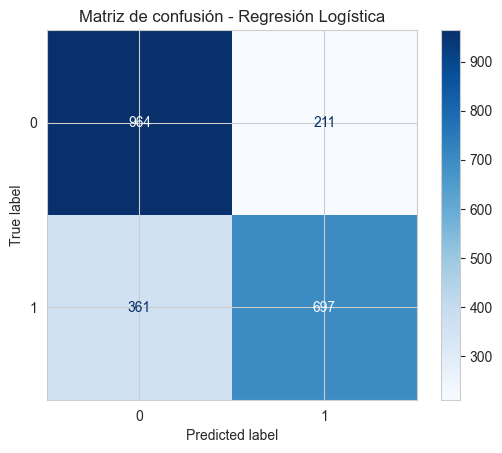

In [14]:
# Regresión logística con los datos escalados
log_reg = LogisticRegression(max_iter=1000, random_state=SEED)

resultado_log_reg = entrena_y_evalua(
    log_reg, "Regresión Logística",
    X_train_scaled, y_train, X_test_scaled, y_test,
)

### Ejercicio 7

Crea un modelo MLP, con sklearn, con dos hidden layers de 100 neuronas c/u y observa sus métricas. Además, registra su tiempo de entrenamiento y de predicciones

MLP (100, 100)
Tiempo de entrenamiento: 3.8786 s
Tiempo de predicción   : 0.0021 s

              precision    recall  f1-score   support

           0      0.802     0.730     0.764      1175
           1      0.727     0.800     0.762      1058

    accuracy                          0.763      2233
   macro avg      0.765     0.765     0.763      2233
weighted avg      0.767     0.763     0.763      2233



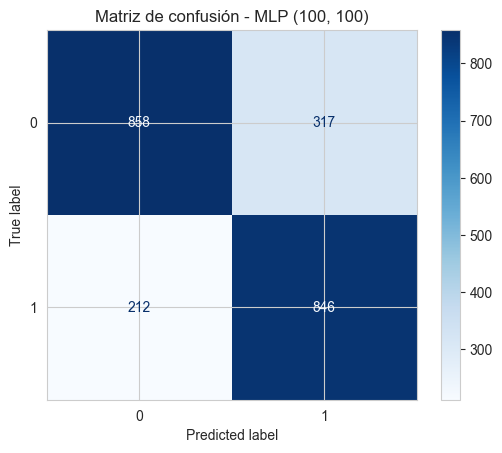

In [15]:
# MLP con DOS hidden layers de 100 neuronas cada una, tal y como pide el enunciado.
# hidden_layer_sizes=(100, 100) -> la tupla indica cuántas neuronas tiene cada capa oculta.
# Subimos max_iter a 500 porque con el valor por defecto (200) no le da tiempo a converger.
mlp = MLPClassifier(
    hidden_layer_sizes=(100, 100),
    max_iter=500,
    random_state=SEED,
)

resultado_mlp = entrena_y_evalua(
    mlp, "MLP (100, 100)",
    X_train_scaled, y_train, X_test_scaled, y_test,
)

### Ejercicio 8

Compara los dos modelos. En un caso real, ¿Con cuál modelo te quedarías? ¿Por qué?

In [16]:
# Juntamos los resultados de ambos modelos en una tabla comparativa
comparativa = pd.DataFrame([resultado_log_reg, resultado_mlp]).set_index("modelo")

# Añadimos una columna que indique cuántas veces más lento es entrenar cada modelo
comparativa["veces_mas_lento"] = (
    comparativa["t_entrenamiento_s"] / comparativa["t_entrenamiento_s"].min()
).round(1)

comparativa.round(4)

,accuracy,precision,recall,f1,t_entrenamiento_s,t_prediccion_s,veces_mas_lento
modelo,,,,,,,
Regresión Logística,0.7438,0.7676,0.6588,0.7091,0.0050,0.0002,1.0
"MLP (100, 100)",0.7631,0.7274,0.7996,0.7618,3.8786,0.0021,771.3


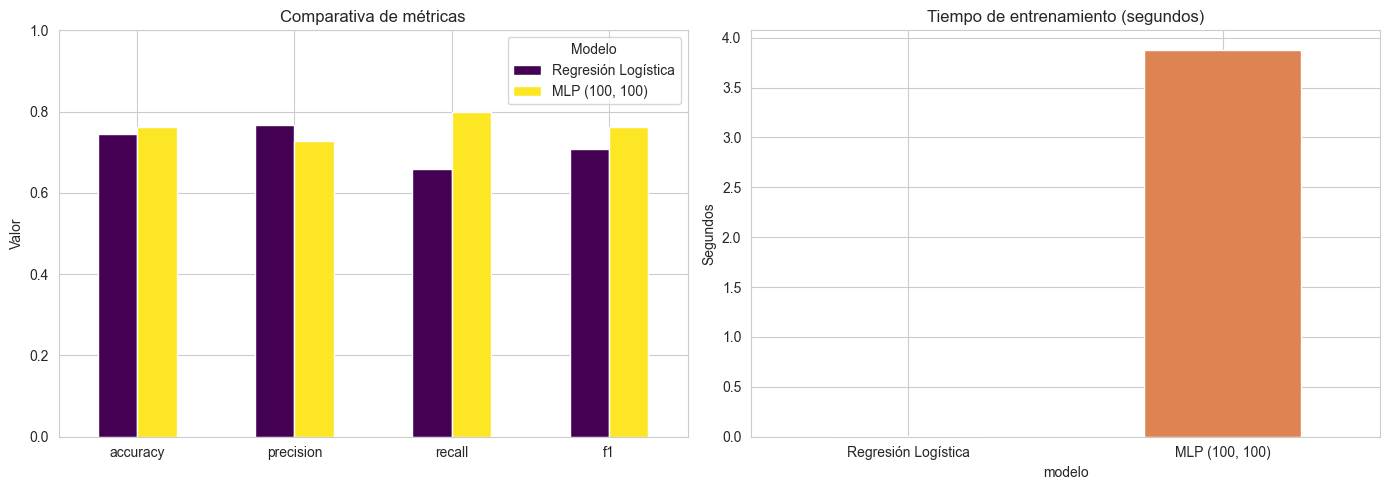

In [17]:
# Lo vemos también en un gráfico: métricas a la izquierda, tiempo a la derecha
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metricas = ["accuracy", "precision", "recall", "f1"]
comparativa[metricas].T.plot(kind="bar", ax=axes[0], rot=0, colormap="viridis")
axes[0].set_title("Comparativa de métricas")
axes[0].set_ylabel("Valor")
axes[0].set_ylim(0, 1)
axes[0].legend(title="Modelo")

comparativa["t_entrenamiento_s"].plot(kind="bar", ax=axes[1], rot=0, color=["#4c72b0", "#dd8452"])
axes[1].set_title("Tiempo de entrenamiento (segundos)")
axes[1].set_ylabel("Segundos")

plt.tight_layout()
plt.show()

### Respuesta: ¿con cuál me quedaría?

**Resultados obtenidos** (métricas referidas a la clase 1, "el cliente contrata el depósito"):

| | Regresión Logística | MLP (100, 100) |
|---|---|---|
| Accuracy | 0,744 | **0,763** |
| Precision | **0,768** | 0,727 |
| Recall | 0,659 | **0,800** |
| F1 | 0,709 | **0,762** |
| Tiempo de entrenamiento | **0,005 s** | 3,88 s (~770 veces más) |
| Tiempo de predicción | 0,0002 s | 0,002 s |

**Lo que nos dicen estos números:** el MLP no es "mejor en todo". Lo que hace realmente es
**cambiar precision por recall**:

- Gana mucho **recall**: pasa de detectar el 66% de los clientes interesados a detectar el **80%**.
  Son 14 puntos, la diferencia más grande entre ambos modelos.
- Pero pierde algo de **precision**: baja de 0,768 a 0,727, es decir, se equivoca más cuando dice
  "este cliente va a contratar".

En accuracy la diferencia es más modesta (2 puntos), pero el **F1 sube de 0,709 a 0,762**, lo que
indica que en conjunto el intercambio le sale rentable al MLP.

**En un caso real me quedaría con el MLP.** El razonamiento es de negocio, no solo de métricas:
para el banco, **no son igual de graves los dos tipos de error**. Un falso positivo cuesta una
llamada de telemarketing que no acaba en contratación (barato). Un falso negativo es un cliente que
sí habría contratado y al que nunca llamamos: ahí perdemos directamente el ingreso. Como el error
caro es el falso negativo, **priorizar el recall tiene sentido**, y es justo donde gana el MLP.

**Sobre el coste computacional:** el MLP tarda del orden de **800 veces más** en entrenar (el
factor exacto baila de una ejecución a otra, pero siempre son varios cientos), aunque en términos
absolutos son **menos de 4 segundos**. Y hay un detalle clave: un modelo así se reentrena de forma
puntual (una vez al mes, por ejemplo), **no** en cada predicción. Lo que sí sería crítico es el
tiempo de **predicción**, y ahí ambos están en milisegundos. Así que el coste extra es perfectamente
asumible.

**Matización importante:** si el banco necesitase *justificar* sus decisiones ante un cliente o ante
un regulador (algo muy habitual en el sector financiero), la cosa cambiaría. La regresión logística
es **interpretable**: podemos mirar sus coeficientes y explicar por qué predice lo que predice. El
MLP es una **caja negra**, y además sus resultados son menos estables porque dependen de la
inicialización aleatoria de los pesos. En ese escenario me quedaría con la logística, asumiendo la
pérdida de recall.

**Conclusión:** el mejor modelo no es simplemente "el que tiene más accuracy", sino el que mejor
encaja con **el coste real de cada tipo de error y las restricciones del negocio**.